# fucking around with decomposing l05 into large & small scales


In [101]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood
from DAPyr.MODELS import deconstruct_Z

reload(dap)

np.set_printoptions(suppress=True)


In [102]:
uoep = {'mu': 0, 'sigma': 2} 
poep = {'mu': 0, 'sigma': 2} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [105]:
e_name = 'L96: sdg'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd_nokde = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 500,
                       'T_train': 300,
                       'train_frac': 1.0,
                       'nle_type': 5,
                       'nle_every': 100, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})



starting experiment L96: sdg


DB: Starting cycle 0
DB: Starting cycle 20
DB: Starting cycle 40
DB: Starting cycle 60
DB: Starting cycle 80
DB: Starting cycle 100
DB: Starting cycle 120
DB: Starting cycle 140
DB: Starting cycle 160
DB: Starting cycle 180
DB: Starting cycle 200
DB: Starting cycle 220
DB: Starting cycle 240
DB: Starting cycle 260
DB: Starting cycle 280
DB: Starting cycle 300
DB: Starting cycle 320
DB: Starting cycle 340
DB: Starting cycle 360
DB: Starting cycle 380
DB: Starting cycle 400
DB: Starting cycle 420
DB: Starting cycle 440
DB: Starting cycle 460
DB: Starting cycle 480


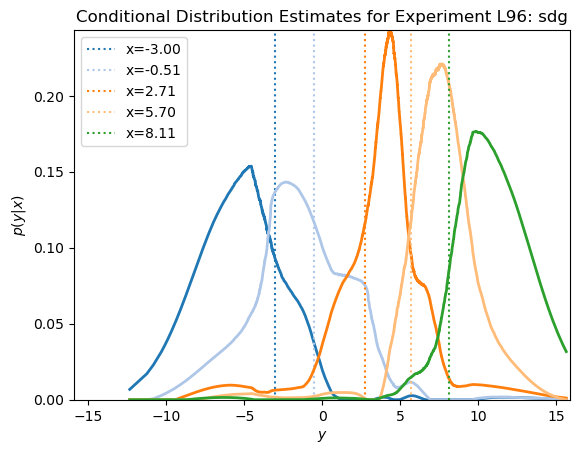

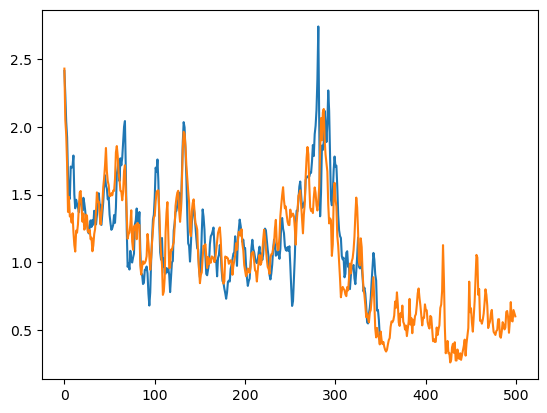

In [106]:
dap.runDA(e_sd_kecd_nokde)
fig, ax = plt.subplots()
dap.plot_pab(e_sd_kecd_nokde, ax=ax, plot_states=True)
plt.plot(e_sd_kecd.rmse)
plt.plot(e_sd_kecd_nokde.rmse)

In [11]:
ens1 = e_sd_kecd.getStates()[0][:,0]
X, Y = deconstruct_Z(ens1)

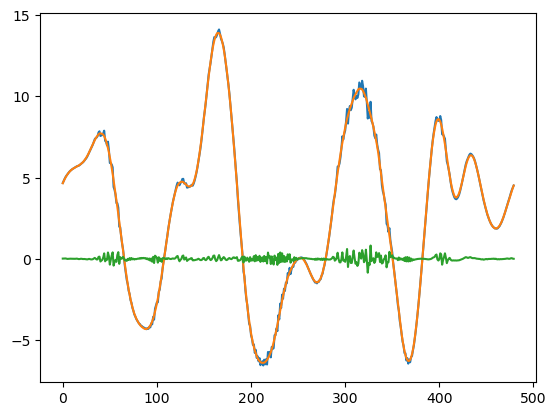

In [12]:
plt.plot(ens1)
plt.plot(X)
plt.plot(Y)


In [26]:
def h_weighted_mat(Y, h, w=3):
    Y = np.asarray(Y)
    N = len(Y)
    
    # 1. Determine the center indices for each step
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    
    # 2. Create the window offsets
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 3. Compute all target indices using broadcasting and modulo for periodicity
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    
    # 4. Construct the transformation matrix W of shape (M, N)
    M = len(centers)
    W = np.zeros((M, N))
    
    # Row-by-row, add 1 to the positions specified by target_indices
    row_indices = np.arange(M)[:, np.newaxis]
    np.add.at(W, (row_indices, target_indices), 1)
    
    # 5. The single matrix operation applied to |Y|
    return W @ np.abs(Y)

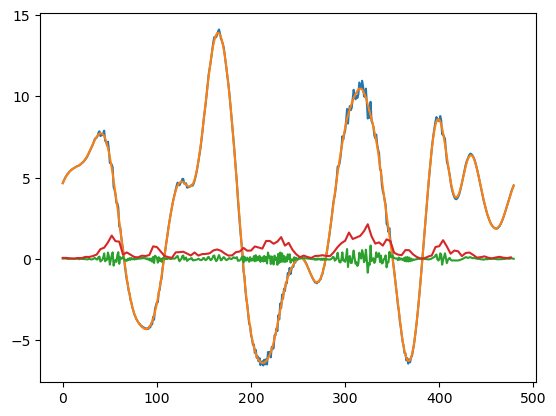

In [33]:
hy = h_weighted_mat(Y, 4, 2)
plt.plot(ens1)
plt.plot(X)
plt.plot(Y)
plt.plot(np.arange(0,480, 4), hy)

In [54]:
def x_slices(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine the center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (2w + 1,)
    
    # 2. Compute periodic target indices
    # Shape: (M, 2w + 1)
    target_indices = (centers + offsets) % N
    M, window_size = target_indices.shape
    
    # 3. Construct the Selection Matrix P of shape (M * window_size, N)
    total_extracted_elements = M * window_size
    P = np.zeros((total_extracted_elements, N))
    
    # Map each position in the flattened output to its corresponding index in X
    row_indices = np.arange(total_extracted_elements)
    col_indices = target_indices.ravel() # Flatten the target indices
    P[row_indices, col_indices] = 1
    
    # 4. Apply the matrix operation and reshape into the final matrix grid
    flat_slices = P @ X
    return flat_slices.reshape(M, window_size)

import numpy as np

def periodic_window_context(X, h, w):
    X = np.asarray(X)
    N = len(X)
    
    # 1. Determine center indices and window offsets
    centers = np.arange(0, N, h)[:, np.newaxis] # Shape: (M, 1)
    offsets = np.arange(-w, w + 1)              # Shape: (1, 2w + 1)
    
    # 2. Compute periodic target indices
    targets = (centers + offsets) % N           # Shape: (M, 2w + 1)
    M = len(centers)
    
    # 3. Construct the Context Selection Matrix P of shape (M * N, N)
    # Initialize the entire matrix with np.nan
    P = np.full((M * N, N), np.nan)
    
    # Calculate which global row indices in P correspond to valid window placements
    step_indices = np.arange(M)[:, np.newaxis]
    rows = (step_indices * N + targets).ravel()
    cols = targets.ravel()
    
    # For active rows, initialize them to 0, then set the target column to 1
    P[rows, :] = 0
    P[rows, cols] = 1
    
    # 4. Perform the single matrix multiplication and reshape to (M, N)
    flat_context = P @ X
    return flat_context.reshape(M, N)

In [82]:
for num in range(120):
    xs = periodic_window_context(X, 4, 10)
    plt.plot(ens1, linewidth=2, c='k')
    plt.plot(X, c='red')
    plt.plot(Y)
    plt.plot(xs[num], linewidth=6, c='red')
    plt.plot((num*4, num*4), (0,2*hy[num]), linewidth=1, c='C1')
    plt.scatter(num*4, 2*hy[num], c='C1')
    plt.savefig(f'../figs/l05-multiscale/demo-l05-multiscale-{num:03}.png')
    plt.close()